In [1]:
pip install numpy pandas textblob scikit-learn matplotlib google-generativeai python-dotenv

# Section 1

In [2]:
import os, random
from datetime import datetime, timedelta
import numpy as np
import pandas as pd

random.seed(42); np.random.seed(42)

SERVICES = ["Massage","Facial","Wellness Package","Manicure",
            "Couples Massage","Deep Tissue Massage","Anti-Ageing Facial"]

POSITIVE = [
    "Absolutely loved it! The therapist was amazing.",
    "Best massage I've ever had. Will definitely rebook.",
    "Wonderful experience from start to finish. Highly recommend!",
    "Exceeded my expectations. The therapist really listened to my needs.",
    "Such a convenient and luxurious experience. Love it!",
    "Five stars all around. The experience was flawless.",
    "My go-to for wellness. Never been disappointed once.",
]
NEUTRAL = [
    "It was okay, nothing special but decent service.",
    "Good experience overall. Average pricing.",
    "The service was fine. Met my basic expectations.",
    "Reasonable service for the price. Would consider rebooking.",
    "Standard massage experience. Nothing to complain about.",
]
NEGATIVE = [
    "Too expensive for what you get. Disappointing.",
    "The therapist was late and seemed unprepared.",
    "Not worth the price. I've had better at half the cost.",
    "Would not recommend. The whole experience felt unprofessional.",
    "Overpriced and underwhelming. Won't be coming back.",
]

ARCHETYPES = {
    "loyalist":     {"weight":0.20,"freq":(8,20), "spend":(150,400),"recency":(1,30),  "services":["Massage","Wellness Package","Couples Massage","Deep Tissue Massage"],"sent":(0.85,0.10,0.05)},
    "occasional":   {"weight":0.30,"freq":(2,5),  "spend":(50,120), "recency":(15,90), "services":["Massage","Facial","Manicure","Anti-Ageing Facial"],                  "sent":(0.40,0.40,0.20)},
    "lapsed":       {"weight":0.20,"freq":(5,15), "spend":(120,350),"recency":(90,365),"services":["Massage","Wellness Package","Facial","Deep Tissue Massage"],          "sent":(0.30,0.30,0.40)},
    "new_explorer": {"weight":0.20,"freq":(1,3),  "spend":(60,180), "recency":(1,20),  "services":SERVICES,                                                               "sent":(0.60,0.30,0.10)},
    "churned":      {"weight":0.10,"freq":(1,3),  "spend":(40,100), "recency":(180,500),"services":["Massage","Facial","Anti-Ageing Facial"],                             "sent":(0.15,0.25,0.60)},
}


In [3]:

def pick_review(d):
    cat = np.random.choice(["pos","neu","neg"], p=d)
    return random.choice(POSITIVE if cat=="pos" else NEUTRAL if cat=="neu" else NEGATIVE)

records, cid, ref = [], 1001, datetime(2024,3,15)
for arch, cfg in ARCHETYPES.items():
    for _ in range(int(800*cfg["weight"])):
        freq  = np.random.randint(*cfg["freq"])
        spend = round(max(np.random.uniform(*cfg["spend"])+np.random.normal(0,15),30),2)
        days  = np.random.randint(*cfg["recency"])
        records.append({
            "Customer_ID": cid,
            "Booking_Frequency": freq,
            "Avg_Spending": spend,
            "Preferred_Service": random.choice(cfg["services"]),
            "Review_Text": pick_review(cfg["sent"]),
            "Last_Activity": (ref-timedelta(days=int(days))).strftime("%Y-%m-%d"),
            "Days_Since_Last_Booking": int(days),
            "Total_Spend": round(spend*freq*np.random.uniform(0.8,1.2),2),
        })
        cid += 1




In [5]:
df_raw = pd.DataFrame(records).sample(frac=1,random_state=42).reset_index(drop=True)
os.makedirs("data", exist_ok=True)


In [6]:
df_raw.to_csv("data/customer_data.csv", index=False)
print(f"Generated {len(df_raw)} customer records → data/customer_data.csv")
display(df_raw.head())

Generated 800 customer records → data/customer_data.csv


,Customer_ID,Booking_Frequency,Avg_Spending,Preferred_Service,Review_Text,Last_Activity,Days_Since_Last_Booking,Total_Spend
0,1697,1,137.77,Wellness Package,Such a convenient and luxurious experience. Lo...,2024-03-09,6,132.68
1,1668,2,93.36,Couples Massage,Not worth the price. I've had better at half t...,2024-02-26,18,191.36
2,1064,11,221.38,Massage,Best massage I've ever had. Will definitely re...,2024-03-10,5,2548.03
3,1534,6,301.98,Deep Tissue Massage,Wonderful experience from start to finish. Hig...,2023-10-13,154,1774.98
4,1067,18,361.47,Massage,Exceeded my expectations. The therapist really...,2024-03-14,1,6625.18


In [7]:
from textblob import TextBlob
from sklearn.preprocessing import StandardScaler


In [8]:

df = df_raw.copy()
df['Booking_Frequency'] = df['Booking_Frequency'].fillna(df['Booking_Frequency'].median())
df['Avg_Spending']      = df['Avg_Spending'].fillna(df['Avg_Spending'].median())
df['Review_Text']       = df['Review_Text'].fillna('')


In [9]:

# Sentiment analysis — TextBlob pretrained lexicon (polarity: -1 to +1)
df['Review_Sentiment'] = df['Review_Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

scaler = StandardScaler()


In [10]:
df[['Booking_Frequency_Norm','Avg_Spending_Norm']] = scaler.fit_transform(
    df[['Booking_Frequency','Avg_Spending']]
)


In [11]:

print(f"Dataset shape: {df.shape}")
print(f"Positive reviews (>0.1):  {(df['Review_Sentiment']>0.1).sum()}")
print(f"Neutral  reviews:         {((df['Review_Sentiment']>=-0.1)&(df['Review_Sentiment']<=0.1)).sum()}")
print(f"Negative reviews (<-0.1): {(df['Review_Sentiment']<-0.1).sum()}")
display(df[['Customer_ID','Booking_Frequency','Avg_Spending','Preferred_Service','Review_Sentiment']].head(8))


Dataset shape: (800, 11)
Positive reviews (>0.1):  549
Neutral  reviews:         137
Negative reviews (<-0.1): 114


,Customer_ID,Booking_Frequency,Avg_Spending,Preferred_Service,Review_Sentiment
0,1697,1,137.77,Wellness Package,0.312500
1,1668,2,93.36,Couples Massage,0.061111
2,1064,11,221.38,Massage,0.500000
3,1534,6,301.98,Deep Tissue Massage,0.600000
4,1067,18,361.47,Massage,0.200000
5,1622,1,168.78,Anti-Ageing Facial,0.000000
6,1347,4,73.11,Manicure,0.200000
7,1491,14,313.84,Deep Tissue Massage,0.061111


In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

X = df[['Booking_Frequency_Norm','Avg_Spending_Norm','Review_Sentiment']].values
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

stats = df.groupby('Cluster')[['Booking_Frequency','Avg_Spending','Review_Sentiment','Days_Since_Last_Booking']].mean()
print("Cluster centroids:")
display(stats.round(2))


Cluster centroids:


,Booking_Frequency,Avg_Spending,Review_Sentiment,Days_Since_Last_Booking
Cluster,,,,
0,2.26,95.36,0.23,87.40
1,15.69,298.74,0.32,55.49
2,10.94,187.80,0.08,167.25
3,9.06,308.23,0.30,134.59


In [14]:

SEGMENT_NAMES = {
    stats['Avg_Spending'].idxmax(): "High-Value Loyalists",
    stats['Days_Since_Last_Booking'].idxmax(): "Lapsed High-Spenders",
    stats['Booking_Frequency'].idxmin(): "New Explorers",
}
for cid in range(4):
    if cid not in SEGMENT_NAMES:
        SEGMENT_NAMES[cid] = "Price-Sensitive Occasionals"

df['Segment'] = df['Cluster'].map(SEGMENT_NAMES)
print("\nSegment counts:")
print(df['Segment'].value_counts())



Segment counts:
Segment
New Explorers                  487
Lapsed High-Spenders           117
High-Value Loyalists            99
Price-Sensitive Occasionals     97
Name: count, dtype: int64


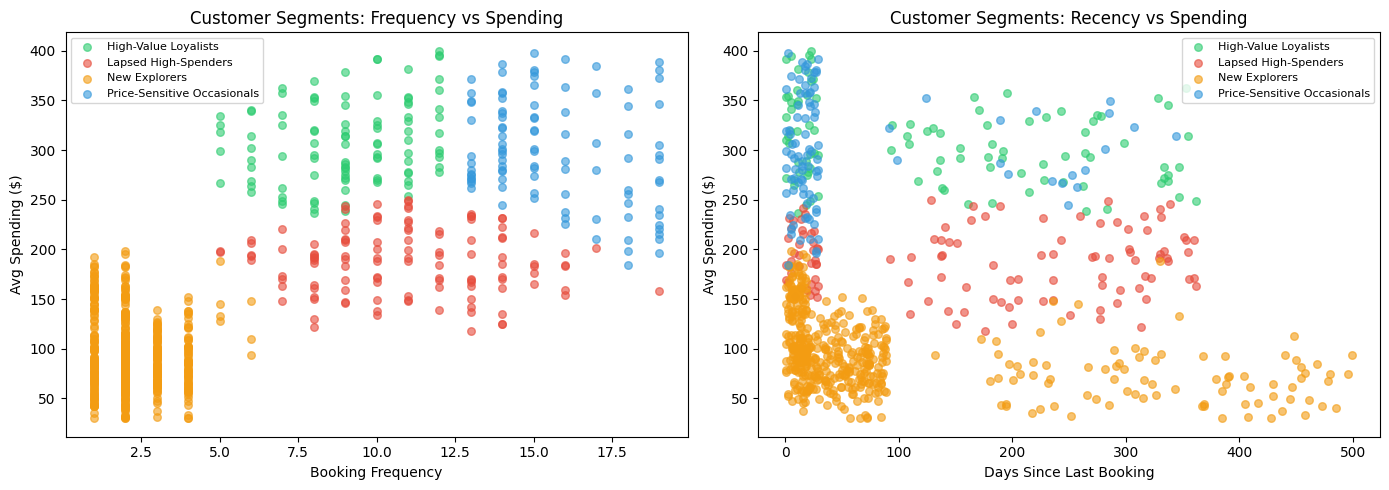

Saved → outputs/customer_segments.png


In [17]:
import matplotlib.pyplot as plt

COLORS = {
    "High-Value Loyalists":       "#2ecc71",
    "Price-Sensitive Occasionals":"#3498db",
    "Lapsed High-Spenders":       "#e74c3c",
    "New Explorers":               "#f39c12",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Booking Frequency vs Avg Spending
for seg, grp in df.groupby('Segment'):
    axes[0].scatter(grp['Booking_Frequency'], grp['Avg_Spending'],
                    c=COLORS[seg], label=seg, alpha=0.6, s=30)
axes[0].set_xlabel("Booking Frequency")
axes[0].set_ylabel("Avg Spending ($)")
axes[0].set_title("Customer Segments: Frequency vs Spending")
axes[0].legend(fontsize=8)

# Plot 2: Days Since Last Booking vs Avg Spending (churn risk view)
for seg, grp in df.groupby('Segment'):
    axes[1].scatter(grp['Days_Since_Last_Booking'], grp['Avg_Spending'],
                    c=COLORS[seg], label=seg, alpha=0.6, s=30)
axes[1].set_xlabel("Days Since Last Booking")
axes[1].set_ylabel("Avg Spending ($)")
axes[1].set_title("Customer Segments: Recency vs Spending")
axes[1].legend(fontsize=8)

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/customer_segments.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved → outputs/customer_segments.png")


## 1.4 Insights & Output Report

In [18]:
# Generate customer_analysis.md report
seg_stats = df.groupby('Segment').agg(
    Count=('Customer_ID','count'),
    Avg_Frequency=('Booking_Frequency','mean'),
    Avg_Spending=('Avg_Spending','mean'),
    Avg_Total_Spend=('Total_Spend','mean'),
    Avg_Sentiment=('Review_Sentiment','mean'),
    Avg_Days_Inactive=('Days_Since_Last_Booking','mean'),
).round(2)

lines = [
    "# Customer Behaviour Analysis — Blys\n\n",
    "## Dataset\n",
    f"- **Records:** {len(df)} synthetic customers\n",
    "- **Fields:** Customer_ID, Booking_Frequency, Avg_Spending, Preferred_Service, Review_Text, Last_Activity, Days_Since_Last_Booking, Total_Spend\n",
    "- **Generation:** Archetype-based synthetic data with realistic booking patterns and sentiment-correlated reviews\n\n",
    "## Preprocessing\n",
    "- Missing values filled with column median\n",
    "- Sentiment extracted from Review_Text using TextBlob (polarity: -1 to +1)\n",
    "- Booking_Frequency and Avg_Spending normalised with StandardScaler\n\n",
    "## Customer Segments (K-Means, k=4)\n\n",
    "| Segment | Count | Avg Frequency | Avg Spending | Avg Sentiment | Avg Days Inactive |\n",
    "|---|---|---|---|---|---|\n",
]
for seg, row in seg_stats.iterrows():
    lines.append(f"| {seg} | {int(row.Count)} | {row.Avg_Frequency} | ${row.Avg_Spending} | {row.Avg_Sentiment} | {row.Avg_Days_Inactive} days |\n")

lines += [
    "\n## Business Recommendations\n\n",
    "### High-Value Loyalists\n",
    "- Highest LTV segment. Assign top-rated therapists to this group.\n",
    "- Offer a loyalty programme (e.g. every 10th booking free) to reinforce retention.\n\n",
    "### Lapsed High-Spenders\n",
    "- Highest churn risk despite historically high spend.\n",
    "- Re-engagement campaign: personalised email with 15% discount on their preferred service.\n",
    "- Target within 90-day inactivity window before they become fully churned.\n\n",
    "### Price-Sensitive Occasionals\n",
    "- Respond well to promotions. Bundle deals (e.g. Massage + Manicure) can increase basket size.\n",
    "- Upsell to Wellness Package with a first-time discount.\n\n",
    "### New Explorers\n",
    "- Recent first-timers with positive sentiment — high conversion potential.\n",
    "- Follow-up within 7 days with a personalised recommendation based on their first service.\n",
    "- Onboarding email series to introduce the full service catalogue.\n",
]

os.makedirs("outputs", exist_ok=True)
with open("outputs/customer_analysis.md", "w") as f:
    f.writelines(lines)
print("Saved → outputs/customer_analysis.md")
print(seg_stats)


Saved → outputs/customer_analysis.md
                             Count  Avg_Frequency  Avg_Spending  \
Segment                                                           
High-Value Loyalists            99           9.06        308.23   
Lapsed High-Spenders           117          10.94        187.80   
New Explorers                  487           2.26         95.36   
Price-Sensitive Occasionals     97          15.69        298.74   

                             Avg_Total_Spend  Avg_Sentiment  Avg_Days_Inactive  
Segment                                                                         
High-Value Loyalists                 2715.20           0.30             134.59  
Lapsed High-Spenders                 2089.44           0.08             167.25  
New Explorers                         210.34           0.23              87.40  
Price-Sensitive Occasionals          4658.59           0.32              55.49  


# Section 2: Content-Based Recommender

In [19]:
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity

In [20]:
SERVICE_CATALOG = pd.DataFrame([
    {"service_id":"SVC001","service_name":"Massage",             "category":"body", "avg_price":120,"duration_min":60, "relaxation_score":0.90,"therapeutic_score":0.70},
    {"service_id":"SVC002","service_name":"Facial",              "category":"face", "avg_price":95, "duration_min":60, "relaxation_score":0.70,"therapeutic_score":0.40},
    {"service_id":"SVC003","service_name":"Wellness Package",    "category":"combo","avg_price":179,"duration_min":120,"relaxation_score":1.00,"therapeutic_score":0.60},
    {"service_id":"SVC004","service_name":"Manicure",            "category":"nails","avg_price":55, "duration_min":45, "relaxation_score":0.40,"therapeutic_score":0.10},
    {"service_id":"SVC005","service_name":"Couples Massage",     "category":"body", "avg_price":220,"duration_min":60, "relaxation_score":0.95,"therapeutic_score":0.65},
    {"service_id":"SVC006","service_name":"Deep Tissue Massage", "category":"body", "avg_price":145,"duration_min":75, "relaxation_score":0.60,"therapeutic_score":0.95},
    {"service_id":"SVC007","service_name":"Anti-Ageing Facial",  "category":"face", "avg_price":120,"duration_min":75, "relaxation_score":0.65,"therapeutic_score":0.50},
])

In [21]:
class ContentBasedRecommender:
    """Content-based service recommender using cosine similarity."""

    def __init__(self):
        self.catalog = SERVICE_CATALOG.copy()
        self.service_vectors = None
        self.customer_vectors = {}
        self._scaler = StandardScaler()
        self._encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        self._spend_scaler = StandardScaler()
        self._svc_idx = {}
        self.fitted = False

    def fit(self, customer_df):
        num = self._scaler.fit_transform(self.catalog[["avg_price","duration_min","relaxation_score","therapeutic_score"]])
        cat = self._encoder.fit_transform(self.catalog[["category"]])
        self.service_vectors = np.hstack([num, cat])
        self._svc_idx = {name: i for i, name in enumerate(self.catalog["service_name"])}
        self._spend_scaler.fit(customer_df[["Avg_Spending"]])
        for _, row in customer_df.iterrows():
            self.customer_vectors[str(row["Customer_ID"])] = self._customer_vec(row)
        self.fitted = True

    def _customer_vec(self, row):
        svc = row["Preferred_Service"]
        if svc not in self._svc_idx:
            return self.service_vectors.mean(axis=0)
        vec = self.service_vectors[self._svc_idx[svc]].copy()
        freq_w    = 0.5 + 0.5 * min(row["Booking_Frequency"] / 10, 1.0)
        spend_w   = 1.0 + 0.2 * np.tanh(float(self._spend_scaler.transform([[row["Avg_Spending"]]])[0][0]))
        recency_w = 0.7 if row.get("Days_Since_Last_Booking", 0) > 180 else 1.0
        return vec * freq_w * spend_w * recency_w

    def recommend(self, customer_id, top_n=3):
        if not self.fitted:
            raise RuntimeError("Call fit() first.")
        if customer_id not in self.customer_vectors:
            return self._cold_start(top_n)
        cvec = self.customer_vectors[customer_id].reshape(1, -1)
        sims = cosine_similarity(cvec, self.service_vectors)[0]
        booked = self.catalog.iloc[int(np.argmax(sims))]["service_name"]
        recs = []
        for idx in np.argsort(sims)[::-1]:
            name = self.catalog.iloc[idx]["service_name"]
            if name == booked:
                continue
            recs.append({"service": name, "confidence": round(float(sims[idx]), 4),
                         "avg_price": float(self.catalog.iloc[idx]["avg_price"])})
            if len(recs) >= top_n:
                break
        return recs

    def evaluate(self, customer_df, k_values=None):
        """Leave-one-out Precision@K evaluation."""
        if k_values is None:
            k_values = [3, 5]
        hits = {k: 0 for k in k_values}
        total = 0
        for _, row in customer_df.iterrows():
            cid = str(row["Customer_ID"])
            actual = row["Preferred_Service"]
            if actual not in self._svc_idx:
                continue
            # Build proxy vector from second-best service
            actual_idx = self._svc_idx[actual]
            sims = cosine_similarity(self.service_vectors[actual_idx].reshape(1,-1), self.service_vectors)[0]
            sims[actual_idx] = -1
            proxy_vec = self.service_vectors[int(np.argmax(sims))]
            orig = self.customer_vectors.get(cid)
            self.customer_vectors[cid] = proxy_vec
            top_recs = [self.catalog.iloc[i]["service_name"]
                        for i in np.argsort(cosine_similarity(proxy_vec.reshape(1,-1), self.service_vectors)[0])[::-1][:max(k_values)]]
            for k in k_values:
                if actual in top_recs[:k]:
                    hits[k] += 1
            total += 1
            self.customer_vectors[cid] = orig if orig is not None else proxy_vec
        results = {f"precision@{k}": round(hits[k]/total, 4) for k in k_values} if total else {}
        results["total_evaluated"] = total
        return results

    def _cold_start(self, top_n):
        return [{"service": r["service_name"], "confidence": float(r["relaxation_score"]), "note": "cold-start"}
                for _, r in self.catalog.sort_values("relaxation_score", ascending=False).head(top_n).iterrows()]




In [22]:
# Fit the recommender
recommender = ContentBasedRecommender()
recommender.fit(df)
print("ContentBasedRecommender fitted.")
print(f"Customers indexed: {len(recommender.customer_vectors)}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

ContentBasedRecommender fitted.
Customers indexed: 800


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

## Evaluation (Precision@K, Leave-One-Out)

In [24]:
# Precision@K (leave-one-out)
eval_results = recommender.evaluate(df, k_values=[3, 5])
print("Evaluation Results:")
for k, v in eval_results.items():
    print(f"  {k}: {v}")




Evaluation Results:
  precision@3: 1.0
  precision@5: 1.0
  total_evaluated: 800


In [25]:
sample_id = str(df['Customer_ID'].iloc[0])
recs = recommender.recommend(sample_id, top_n=3)
print(f"\nSample recommendations for customer {sample_id}:")
for r in recs:
    print(f"  {r['service']} — confidence: {r['confidence']}, avg price: ${r['avg_price']}")





Sample recommendations for customer 1697:
  Couples Massage — confidence: 0.2797, avg price: $220.0
  Deep Tissue Massage — confidence: 0.0004, avg price: $145.0
  Massage — confidence: -0.0466, avg price: $120.0


In [26]:
print("\nCold-start (unknown customer):")
for r in recommender.recommend("UNKNOWN_999", top_n=3):
    print(f"  {r['service']} — {r.get('note','')}")


Cold-start (unknown customer):
  Wellness Package — cold-start
  Couples Massage — cold-start
  Massage — cold-start


In [27]:
import pickle, os
os.makedirs("models", exist_ok=True)
with open("models/recommendation_model.pkl", "wb") as f:
    pickle.dump(recommender, f)
print("Saved → models/recommendation_model.pkl")


Saved → models/recommendation_model.pkl


# Section 3: ChatbotModel with LLM Tool-Calling

In [49]:
import os, json, pickle
from google import genai
from google.genai import types
from google.colab import userdata

client = genai.Client(api_key=userdata.get("GOOGLE_API_KEY"))
GEMINI_MODEL = "gemini-2.5-flash"

In [50]:
print("Testing Gemini...")
result = chatbot.predict("Hello, Gemini!", session_id="test_session")
print(f"Gemini's response: {result['response']}")

Testing Gemini...
Gemini's response: Hello there! I'm here to help you with Blys. How can I assist you today with your bookings, rescheduling, cancellations, or pricing? 😊


In [51]:
def reschedule_booking(booking_id: str, new_datetime: str) -> dict:
    return {
        "status": "pending_confirmation",
        "message": f"Reschedule request sent to your therapist for {new_datetime}. You'll be notified once confirmed.",
        "booking_id": booking_id,
    }


In [52]:
def cancel_booking(booking_id: str) -> dict:
    return {
        "status": "cancelled",
        "message": f"Booking {booking_id} cancelled. Refund processed within 5-10 business days.",
        "booking_id": booking_id,
    }

In [53]:
TOOL_FUNCTIONS = {"reschedule_booking": reschedule_booking, "cancel_booking": cancel_booking}

GEMINI_TOOLS = [types.Tool(function_declarations=[
    types.FunctionDeclaration(
        name="reschedule_booking",
        description="Reschedule an existing booking to a new date and time.",
        parameters={
            "type": "object",
            "properties": {
                "booking_id": {"type": "string", "description": "Booking ID. Use 'LATEST' if not provided."},
                "new_datetime": {"type": "string", "description": "New date/time, e.g. '30 Mar 2025 10:00 AM'"},
            },
            "required": ["booking_id", "new_datetime"],
        },
    ),
    types.FunctionDeclaration(
        name="cancel_booking",
        description="Cancel an existing booking. Always confirm with the customer first.",
        parameters={
            "type": "object",
            "properties": {
                "booking_id": {"type": "string", "description": "Booking ID. Use 'LATEST' if not provided."},
            },
            "required": ["booking_id"],
        },
    ),
])]

In [54]:
SYSTEM_PROMPT = """You are a friendly AI assistant for Blys, an on-demand wellness platform.
Help customers with bookings, rescheduling, cancellations, and pricing.
- For rescheduling: ask for the new date/time if not provided, then call reschedule_booking.
- For cancellations: confirm before calling cancel_booking.
- For new bookings: guide them to the Blys app.
- Keep responses warm, professional, and concise."""

INTENT_KEYWORDS = {
    "reschedule_booking": ["reschedule","rebook","change my booking","change the date","move my appointment"],
    "cancel_booking":     ["cancel","cancellation","call off","don't want my booking"],
    "booking_new":        ["book a","make a booking","new booking","i want to book","schedule a"],
    "pricing_inquiry":    ["how much","price","cost","pricing","fee","charge","what does"],
}

In [55]:
def classify_intent(text: str, active_intent: str = None) -> str:
    if active_intent:
        return active_intent
    low = text.lower()
    for intent, kws in INTENT_KEYWORDS.items():
        if any(kw in low for kw in kws):
            return intent
    return "general_inquiry"

def _build_gemini_contents(history: list[dict]) -> list:
    """Convert chat history to Gemini Content objects."""
    contents = []
    for msg in history:
        role = msg["role"]
        content = msg["content"]
        if role == "user":
            contents.append(types.Content(role="user", parts=[types.Part.from_text(text=content)]))
        elif role == "assistant":
            contents.append(types.Content(role="model", parts=[types.Part.from_text(text=content)]))
    return contents

In [56]:
class ChatbotModel:
    """Gemini-powered chatbot with tool-calling and multi-turn session state."""

    def __init__(self):
        self.sessions = {}  # session_id -> {"history": [], "active_intent": None}

    def predict(self, user_input: str, session_id: str = "default") -> dict:
        if session_id not in self.sessions:
            self.sessions[session_id] = {"history": [], "active_intent": None}
        session = self.sessions[session_id]
        history = session["history"]
        history.append({"role": "user", "content": user_input})

        intent = classify_intent(user_input, session["active_intent"])
        action_taken = None

        contents = _build_gemini_contents(history)
        config = types.GenerateContentConfig(
            system_instruction=SYSTEM_PROMPT,
            tools=GEMINI_TOOLS if intent in ("reschedule_booking", "cancel_booking") else None,
        )

        if intent in ("reschedule_booking", "cancel_booking", "booking_new"):
            session["active_intent"] = intent
            resp = client.models.generate_content(model=GEMINI_MODEL, contents=contents, config=config)
            candidate = resp.candidates[0]

            # Check for function call
            fn_part = next((p for p in candidate.content.parts if p.function_call), None)
            if fn_part:
                fn_name = fn_part.function_call.name
                fn_args = dict(fn_part.function_call.args)
                action_result = TOOL_FUNCTIONS[fn_name](**fn_args)
                action_taken = {"tool": fn_name, "args": fn_args, "result": action_result}
                session["active_intent"] = None

                # Send tool result back for natural language response
                contents.append(types.Content(role="model", parts=[types.Part(function_call=fn_part.function_call)]))
                contents.append(types.Content(role="user", parts=[types.Part.from_function_response(
                    name=fn_name, response=action_result
                )]))
                followup = client.models.generate_content(
                    model=GEMINI_MODEL, contents=contents,
                    config=types.GenerateContentConfig(system_instruction=SYSTEM_PROMPT)
                )
                response = followup.candidates[0].content.parts[0].text
            else:
                response = "".join(p.text for p in candidate.content.parts if p.text)
        else:
            resp = client.models.generate_content(model=GEMINI_MODEL, contents=contents, config=config)
            response = "".join(p.text for p in resp.candidates[0].content.parts if p.text)

        history.append({"role": "assistant", "content": response})
        if len(history) > 20:
            session["history"] = history[-20:]

        return {"response": response, "intent": intent, "action_taken": action_taken}

chatbot = ChatbotModel()
print("ChatbotModel initialised.")

ChatbotModel initialised.


In [60]:
# Demo: multi-turn reschedule flow
print("DEMO: Reschedule Booking Flow")

demo_session = "demo_reschedule"
turns = [
    "Can I reschedule my booking?",
    "Yes",
    "30 Mar 2025 10 am",
]

for msg in turns:
    result = chatbot.predict(msg, session_id=demo_session)
    print(f"\nCustomer: {msg}")
    print(f"AI:       {result['response']}")
    print(f"[intent: {result['intent']} | action: {result['action_taken']}]")


DEMO: Reschedule Booking Flow

Customer: Can I reschedule my booking?
AI:       Yes, you can reschedule your booking. What is the new date and time you would like to move your booking to?
[intent: reschedule_booking | action: None]

Customer: Yes
AI:       I can help you reschedule your booking. Please tell me the **new date and time** you would like to move your booking to. For example, "April 15th at 2 PM" or "next Friday at 10 AM."
[intent: reschedule_booking | action: None]

Customer: 30 Mar 2025 10 am
AI:       Your rescheduling request for March 30, 2025, at 10:00 AM has been sent to your therapist. You will be notified once it's confirmed! Is there anything else I can help you with today?
[intent: reschedule_booking | action: {'tool': 'reschedule_booking', 'args': {'booking_id': 'LATEST', 'new_datetime': '30 Mar 2025 10:00 AM'}, 'result': {'status': 'pending_confirmation', 'message': "Reschedule request sent to your therapist for 30 Mar 2025 10:00 AM. You'll be notified once con

In [61]:
print("DEMO: Pricing Inquiry")
r = chatbot.predict("How much does a deep tissue massage cost?", session_id="demo_pricing")
print(f"Customer: How much does a deep tissue massage cost?")
print(f"AI:       {r['response']}")
print(f"[intent: {r['intent']}]")

DEMO: Pricing Inquiry
Customer: How much does a deep tissue massage cost?
AI:       The cost of a deep tissue massage can vary depending on your location, the duration of the service, and any current promotions.

For the most accurate and up-to-date pricing, please check the Blys app! You'll be able to see all the available options and costs for your area there. 😊
[intent: pricing_inquiry]


In [62]:
import pickle, os
os.makedirs("models", exist_ok=True)
with open("models/chatbot_model.pkl", "wb") as f:
    pickle.dump(chatbot, f)
print("Saved → models/chatbot_model.pkl")


Saved → models/chatbot_model.pkl
